# Phase field crystal

___

In this demonstration, we shall look at the phase field module of `tostada.physics` to realise various morphologies and study their statistical properties. The phase-field crystal (PFC) model is a generalised mesoscopic model that describes the dynamics of crystal formation. Similar to the Monte-Carlo method, it is based on a real-valued free energy functional, which is minimized to find the equilibrium state of the system. The only difference is that in Monte-Carlo (or Molecular Dynamics) approach, discrete objects are distributed in space whereas here, a continuous distribution of a phase field is realised.
PFC can be used to study a wide range of phenomena, including the defect formation, the dynamics of grain boundaries, and the growth of crystals with different symmetries.

The generalized equation we are solving is given by:
### $\frac{\partial \psi(\textbf{r},t)}{\partial t} = D\triangledown^2\mu(\textbf{r},t) + \triangledown \cdot \eta(\textbf{r},t)$

where $\psi(\textbf{r},t)$ is the evolving phase field, $\mu(\textbf{r},t)$ is the chemical potential given as $\mu = \frac{\delta F}{\delta \psi}$ and $\eta(\textbf{r},t)$ is the perturbative Gaussian white noise field.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost
from tostada.physics.phase_field_dynamics import PhaseField

GPU detected. Using CUDA.
Using MPI version 4.1, 1 processes
GPU detected. Using CUDA.
GPU detected. Using CUDA
Using JAX devices: [CudaDevice(id=0)]


E0108 05:44:14.573420 2785914 cuda_context.cc:141] The primary context is active and has a different flag set (128) than the desired flag set (0).


First, let us create a crystal with hexagonal local symmetry. The free energy for this can be accessed when initializing the `PhaseField` object via `model='pfc_hex'`. The free energy functional for this state is given by:

### $F_{\text{pfc}} = \large{\int} \small \left( [r + (q_0^2+\triangledown^2)^2]\frac{\psi^2}{2} + \frac{\psi^4}{4} + G(\psi)\right) d\textbf{r}$

where the first two terms in the integrand correspond to the traditional PFC free energy for a hexatic distribution and $G(\psi)$ is the perturbative term.

In [ ]:
ph = PhaseField(model='pfc_hex', # the free energy functional that needs to be minimized. Available: `cahn_hilliard`,`swift_hohenberg`,`ks_damped`,`pfc_hex`,`pfc_bcc`,`pfc_fcc`,`pfc_square`,`pfc_cubic`
                N=200, # Number of pixels along each axes (2D or 3D)
                p=-0.35, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.005, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=10000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=100000, # total number of time iterations,
                resolution=0.01 # microns per pixel
                )

Now that system is initialized, one can time evolve the fields using `Phasefield.solve()`. Since chemical potential for `pfc_hex` takes two additional arguments `r` and `q0`, these can be passed directly as `Phasefield.solve(r=r0,q0=q0)`.

Initial mean value: 0.4983


Solving Phase field equation:   0%|          | 0/100000 [00:00<?, ?it/s]

Time for 10000 iterations: 8.63s (1158.66 it/s)
t=50.0000: Solid: 31.306%
(200, 200) (200, 200)
Hyperuniformity of the structure = [9.98744681e-05]
Mean center-to-center distance = [0.05799609]
Hyperuniformity=[9.98744681e-05], Dmean=[0.05799609]
Time for 10000 iterations: 9.23s (1083.87 it/s)
t=100.0000: Solid: 31.808%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00019091]
Mean center-to-center distance = [0.05979715]
Hyperuniformity=[0.00019091], Dmean=[0.05979715]
Time for 10000 iterations: 9.04s (1106.17 it/s)
t=150.0000: Solid: 31.866%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00022538]
Mean center-to-center distance = [0.05979715]
Hyperuniformity=[0.00022538], Dmean=[0.05979715]
Time for 10000 iterations: 9.09s (1100.15 it/s)
t=200.0000: Solid: 31.580%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00023011]
Mean center-to-center distance = [0.05979715]
Hyperuniformity=[0.00023011], Dmean=[0.05979715]
Time for 10000 iterations: 8.84s 

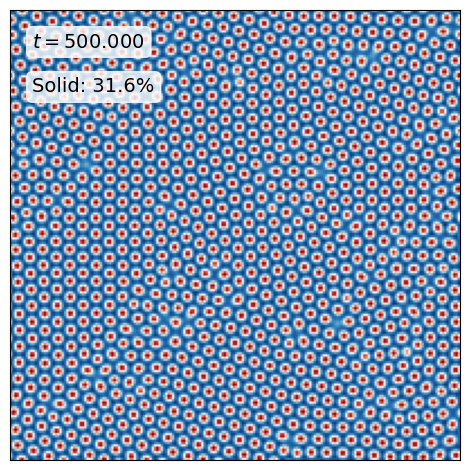

In [3]:
ph.solve(r=-0.5,q0=1)

The mean value of $\psi(\textbf{r},t)$ is recorded at each `self.frame_iter` during the time evolution along with other calculated parameters. 

(0.0, 1.0)

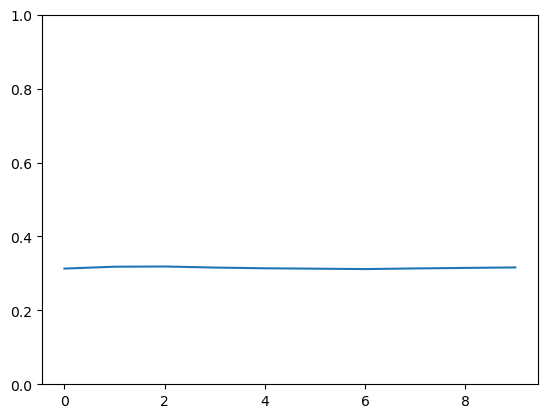

In [5]:
plt.plot(ph.mean_psi_history)
plt.ylim(0,1)

The final state at the last time step can be accessed via `Phasefield.final_state` instance. This is a `PhaseDistribution` and so it can be visualized using `tostada.Visualize`.

(200, 200) (200, 200)


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Z ($\\mathrm{\\mu}$m)'>

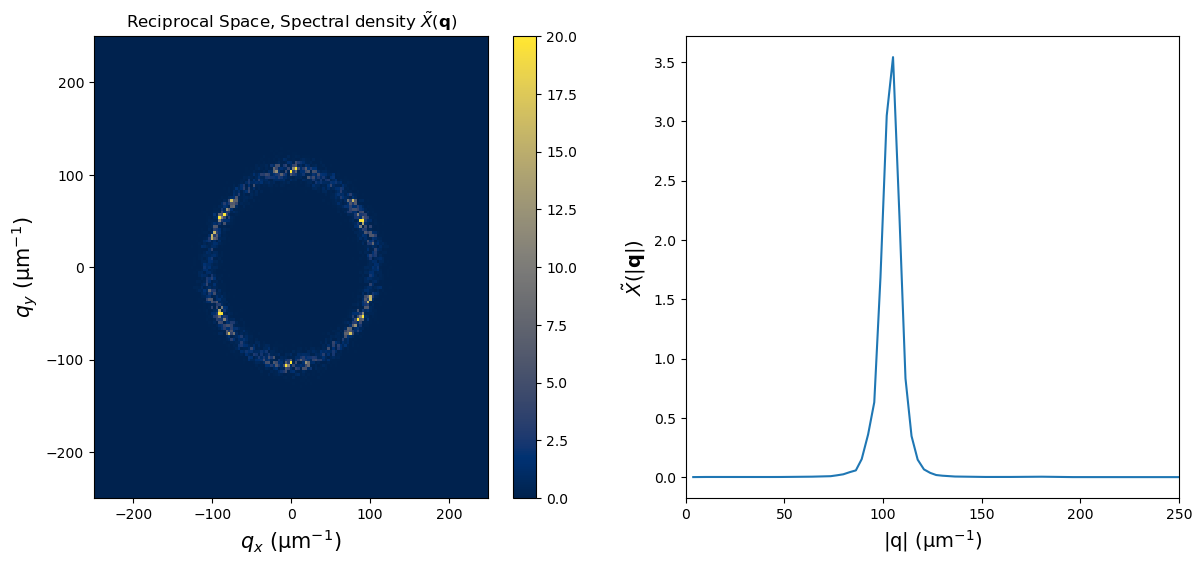

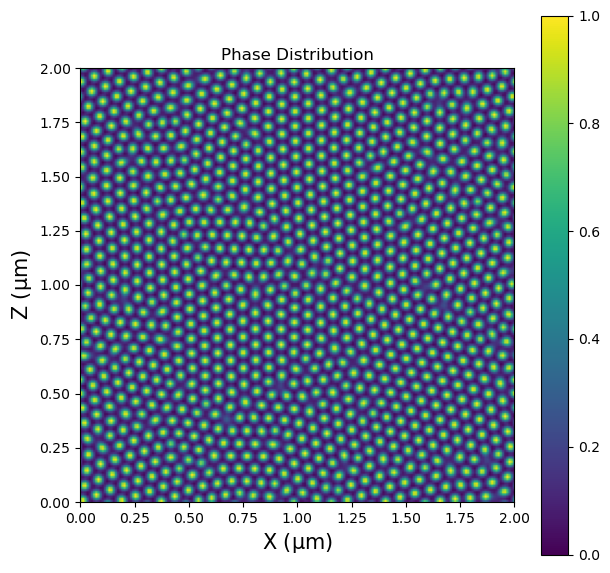

In [10]:
phasedist = ph.final_state
fig = tost.Visualize(phasedist)
fig.plot_reciprocal_space(kmax=250)
fig.plot_distribution()

The system is seen to obey a hexatic symmetry with such a free energy. The phase distribution exhibits several localized maximas, each of which can be identified as the average location of atoms/particles in a grand canonical ensemble (varying number of particles). 
Also, worth noting is that absense of a peak at $\tilde{X}(q=0)$ indicates the phase distribution obeys periodicity in the xy-plane. This is because the laplacian of fields are taken at each time step are done using periodic boundary condition.

In this demonstration, the system is 2D but the phase field model in `tostada` can be used to create 3D phase distributions with face-centered crystal (FCC) and Body-Centered crystal (BCC) using `pfc_fcc` and `pfc_bcc`, respectively. For 2D system, a square lattice symmetry can be obtained using `pfc_square`.

___

In [11]:
ph = PhaseField(model='pfc_square', # the free energy functional that needs to be minimized. Available: `cahn_hilliard`,`swift_hohenberg`,`ks_damped`,`pfc_hex`,`pfc_bcc`,`pfc_fcc`,`pfc_square`,`pfc_cubic`
                N=200, # Number of pixels along each axes (2D or 3D)
                p=0.2, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.0001, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=10000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=50000, # total number of time iterations,
                resolution=0.01, # microns per pixel
                D=0.01
                )

In [12]:
import cupy as cp
ch = ph.initialize_lattice_2(noise=0.15)
phase_init = tost.PhaseDistribution(cp.asnumpy(ch),resolution=1)
#ph.initial_state = phase_init.image # initialized psi(x,y)
xq = phase_init.ReciprocalSpace()[0]
kx=np.fft.fftshift(xq[0]) #tostada internally fftshifts to get [-q, 0, q]. For this solver, we fftshift again to get [0, q, -q]
ky = np.fft.fftshift(xq[1])

Initial mean value: 0.4991
(200, 200) (200, 200)


Initial mean value: 0.4994


Solving Phase field equation:   0%|          | 0/50000 [00:00<?, ?it/s]

Time for 10000 iterations: 8.88s (1125.76 it/s)
t=1.0000: Solid: 50.197%
(200, 200) (200, 200)
Time for 10000 iterations: 8.99s (1112.90 it/s)
t=2.0000: Solid: 50.013%
(200, 200) (200, 200)
Time for 10000 iterations: 9.01s (1110.41 it/s)
t=3.0000: Solid: 50.166%
(200, 200) (200, 200)
Time for 10000 iterations: 9.02s (1108.49 it/s)
t=4.0000: Solid: 49.952%
(200, 200) (200, 200)
Time for 10000 iterations: 8.99s (1111.98 it/s)
t=5.0000: Solid: 50.036%
(200, 200) (200, 200)
Total computation time: 45.00s (1111.10 it/s)
Animation saved to Phasefield_gifs/phase_evolution-2d-D=0.01-p=0.2_pfc_square.gif


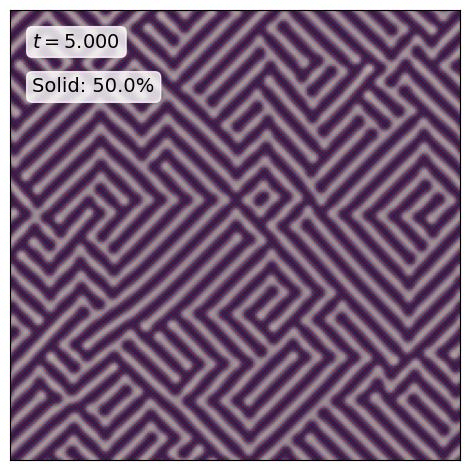

In [13]:
ph.solve(compute_hyperuniformity=False, # turning this off to avoid computation of hyperuniformity 
         kx = cp.asarray(kx), 
         ky = cp.asarray(ky), 
         eps = -0.5,
         r = -0.5,q1=1,q2=1
         )

___

An interesting case arises when the chemical potential $\mu$ of the PFC case is directly time evolved as opposed to $\triangledown^2 \mu$. The resulting equation is called the _Swift-Hohenberg_ equation where the mass (proportional to the mean value of $\psi$) is not conserved. This can be accessed via `model='swift_hohenberg'` in the `Phasefield` initialization.

In [ ]:
ph = PhaseField(model='swift_hohenberg', 
                N=200, # Number of pixels along each axes (2D or 3D)
                p=-0.35, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.005, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=10000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=100000, # total number of time iterations,
                resolution=0.01 # microns per pixel
                )

Initial mean value: 0.5011


Solving Phase field equation:   0%|          | 0/100000 [00:00<?, ?it/s]

Time for 10000 iterations: 7.61s (1314.34 it/s)
t=50.0000: Solid: 49.980%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00078692]
Mean center-to-center distance = [0.06167335]
Hyperuniformity=[0.00078692], Dmean=[0.06167335]
Time for 10000 iterations: 7.56s (1322.20 it/s)
t=100.0000: Solid: 49.172%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.000395]
Mean center-to-center distance = [0.06167335]
Hyperuniformity=[0.000395], Dmean=[0.06167335]
Time for 10000 iterations: 7.37s (1356.61 it/s)
t=150.0000: Solid: 49.532%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00023747]
Mean center-to-center distance = [0.06167335]
Hyperuniformity=[0.00023747], Dmean=[0.06167335]
Time for 10000 iterations: 7.53s (1327.90 it/s)
t=200.0000: Solid: 50.368%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00026374]
Mean center-to-center distance = [0.06167335]
Hyperuniformity=[0.00026374], Dmean=[0.06167335]
Time for 10000 iterations: 7.62s (1312.35 it/

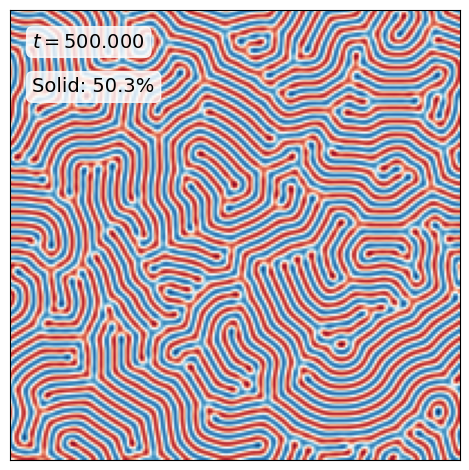

In [7]:
ph.solve(r=-0.5,q0=1)

One can see that for the exact same parameters used for the first case, here the morphology obtained is quite different (labyrinth type structures). 

___

The same phase field model can be used to solve Cahn-Hilliard equation upon choosing the right chemical potential. This is done by setting `model='cahn_hilliard'`. The equation for evolution is given by:

$\Large \frac{\partial \psi(\textbf{r},t)}{\partial t} = D\triangledown^2 \cdot \left(  \psi(\textbf{r},t)^3 - \psi(\textbf{r},t) - \gamma \triangledown^2 \psi(\textbf{r},t) \right)$

Cahn-Hilliard equation describes the physics of phase separation for different initial conditions. Since we are using the phase field model, here $\psi(\textbf{r},t)$ can be interpretted as a concentration field $c(\textbf{r},t)$. Please note that the previous `Cahn_Hilliard.py` is now redudant as the outputs of each are identical.

In [ ]:
ph = PhaseField(model='cahn_hilliard', 
                N=200, # Number of pixels along each axes (2D or 3D)
                p=-0.35, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.005, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=10000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=100000, # total number of time iterations,
                resolution=0.01 # microns per pixel
                )

Let us use the same initial conditions as before. Additionally, one needs to be pass $\gamma$ to define the chemical potential. This parameter controls the interfacial width (smaller the value, thinner the width between two phases).

Initial mean value: 0.4999


Solving Phase field equation:   0%|          | 0/100000 [00:00<?, ?it/s]

Time for 10000 iterations: 7.46s (1339.85 it/s)
t=50.0000: Solid: 30.815%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00021896]
Mean center-to-center distance = [0.08551948]
Hyperuniformity=[0.00021896], Dmean=[0.08551949]
Time for 10000 iterations: 7.64s (1308.30 it/s)
t=100.0000: Solid: 31.327%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00053381]
Mean center-to-center distance = [0.10298518]
Hyperuniformity=[0.00053381], Dmean=[0.10298519]
Time for 10000 iterations: 7.57s (1321.82 it/s)
t=150.0000: Solid: 31.708%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00095328]
Mean center-to-center distance = [0.12187598]
Hyperuniformity=[0.00095328], Dmean=[0.12187597]
Time for 10000 iterations: 7.63s (1311.24 it/s)
t=200.0000: Solid: 31.866%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.0014887]
Mean center-to-center distance = [0.13854384]
Hyperuniformity=[0.0014887], Dmean=[0.13854384]
Time for 10000 iterations: 7.51s (1330.72 i

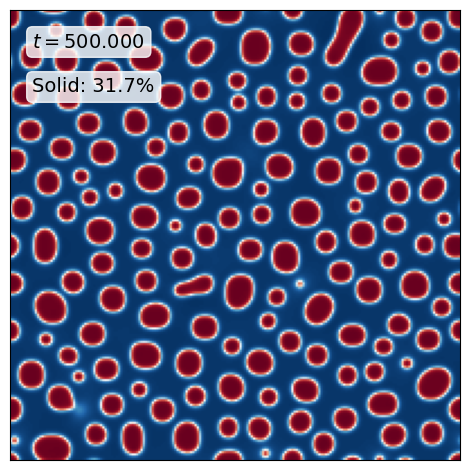

In [34]:
ph.solve(gamma=0.5)

One can see that by setting $p<0$, one phase is more abundant than the other. Consequently, the two separated phases give rise to a polydisperse colloidal system (spherical droplets with varying radii). Upon looking at the generated `.gif` for this simulation, it is apparent that the smaller radii droplets are absorbed by diffusing into bigger droplets (Ostwald ripening). 

We can analyze the shape statistics of these droplets by calling the `Morphology` class through `PhaseDistribution.get_morphological_parameters()`

In [36]:
ph.final_state.image = np.where(ph.final_state.image>0.5,1,0)
mor = ph.final_state.get_morphological_parameters()

Morphology object created


/home/prerak/tostada/src/tostada/Statistics.py:336: RuntimeWarning: invalid value encountered in divide
  thetas[i,:] = np.nan_to_num(np.angle(psi_)/s)


<Axes: xlabel='X ($\\mathrm{\\mu}$m)', ylabel='Y ($\\mathrm{\\mu}$m)'>

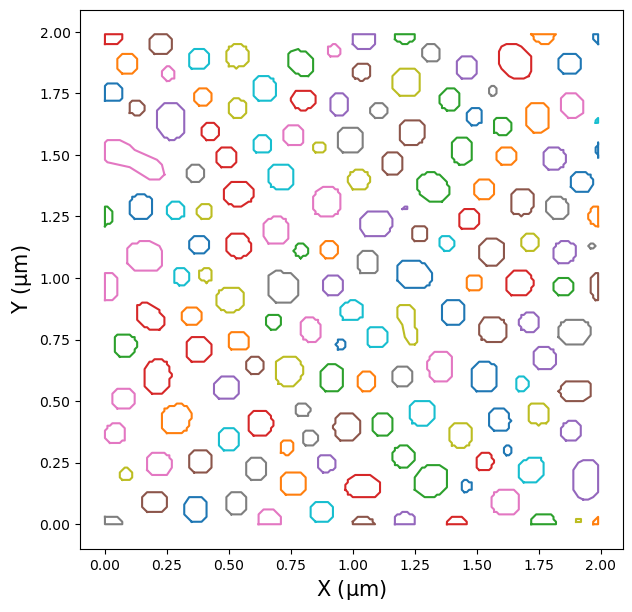

In [38]:
fig = tost.Visualize(ph.final_state)
fig.plot_detected_polygons()

The shape statistics for these detected objects are evaluated using Minkowski structure metrics. For simplicity, here we only look at the circumference of each droplet. This is accessible via `Morphology.psi[:,0]` where the zeroth coefficient of each detected object is queried. 

Text(0.5, 0, 'circumference distribution')

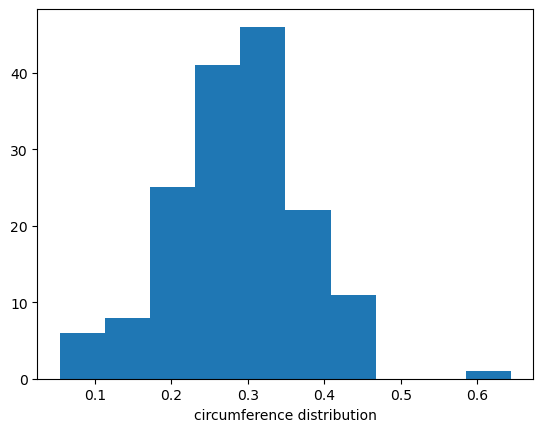

In [43]:
plt.hist(mor.psi[:,0],bins=10)
plt.xlabel('circumference distribution')

To obtain a different phase distribution from the time evolution, one can tune the mean value $\psi_0$ of the initial field. Let us now set $\psi_0 = 0$

In [ ]:
ph = PhaseField(model='cahn_hilliard', 
                N=200, # Number of pixels along each axes (2D or 3D)
                p=0, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.005, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=5000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=30000, # total number of time iterations,
                resolution=0.01 # microns per pixel
                )

Initial mean value: 0.5018


Solving Phase field equation:   0%|          | 0/30000 [00:00<?, ?it/s]

Time for 5000 iterations: 3.65s (1369.12 it/s)
t=25.0000: Solid: 49.896%
(200, 200) (200, 200)
Hyperuniformity of the structure = [6.49739331e-05]
Mean center-to-center distance = [0.07286124]
Hyperuniformity=[6.49739331e-05], Dmean=[0.07286125]
Time for 5000 iterations: 3.70s (1349.72 it/s)
t=50.0000: Solid: 50.058%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00066027]
Mean center-to-center distance = [0.08551948]
Hyperuniformity=[0.00066027], Dmean=[0.08551949]
Time for 5000 iterations: 3.65s (1370.77 it/s)
t=75.0000: Solid: 50.006%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00110965]
Mean center-to-center distance = [0.10854603]
Hyperuniformity=[0.00110965], Dmean=[0.10854603]
Time for 5000 iterations: 3.73s (1341.12 it/s)
t=100.0000: Solid: 49.787%
(200, 200) (200, 200)
Hyperuniformity of the structure = [0.00190114]
Mean center-to-center distance = [0.12187598]
Hyperuniformity=[0.00190114], Dmean=[0.12187597]
Time for 5000 iterations: 3.65s (1371.5

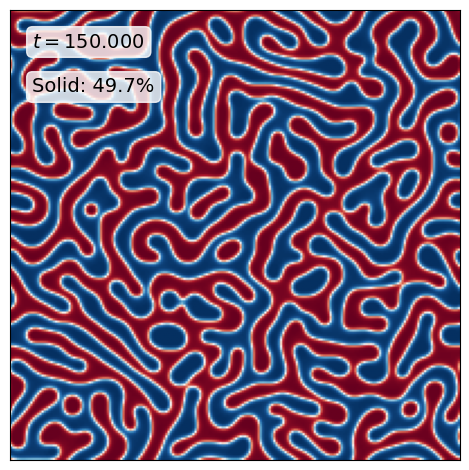

In [7]:
ph.solve(gamma=0.5)

The separated phases are now more connected since the phases are equal in proportion (volume fraction $\phi=0.5$). 

___

`tostada.Phasefield` model can also be used to solve the Kuramoto-Sivashinsky equation (KS equation). It is a non-linear partial differential equation which models complex spatio-temporal chaos. The equation is given by:

$\Large \frac{\partial \psi(\textbf{r},t)}{\partial t} = -\alpha \psi(\textbf{r},t) + \nu \triangledown^2 \psi(\textbf{r},t) - \kappa  \triangledown^4 \psi(\textbf{r},t) + \frac{\lambda}{2}( \triangledown \psi(\textbf{r},t) )^2 $

For the regular KS equation, $\alpha=0$. By setting $\alpha>0$, one can dampen the chaos and allow mode selection. Let us explore this by setting `model='ks_damped'`. 

#### <span style="color:red"> Please note, KS equation (damped or undamped version) is inherently non-variational. Meaning, it does not lead to minimization of a free energy functional and so the chemical potential that gets defined internally in tostada using `model='ks_damped'` is superficial and does not carry any physical meaning. </span>


In [7]:
ph = PhaseField(model='ks_damped', 
                N=200, # Number of pixels along each axes (2D or 3D)
                p=0.5, # mean value of psi(r)
                is_3D=False, # 2D or 3D option
                dt=0.005, # time stepping. Smaller dt => more stable the evolution. Change when moving from 2D to 3D and when changing free energies
                frame_iter=5000, # frequency of analyzing phase distribution throughout the evolution. Larger this number, quicker the phase evolution  
                num_iter=100000, # total number of time iterations,
                resolution=0.01 # microns per pixel
                )

A particular initialized state can also be passed to the `PhaseField`. 

In [8]:
import cupy as cp
ch = ph.initialize_lattice_2(noise=0.15)
phase_init = tost.PhaseDistribution(cp.asnumpy(ch),resolution=1)
ph.initial_state = phase_init.image # initialized psi(x,y)

Initial mean value: 0.5000


The algorithm used for solving the KS equation is semi-spectral, meaning the gradient, laplacian and the biharmonic operators are expressed in the fourier-space and the non-linear terms are treated separately from the linear terms. For the time-evolution, the resulting quantities are inverse fourier transformed to real-space at each time-step.

For this reason, we must first extract the wave-vectors $(q_x,q_y)$ for the phase-field. This can be conveniently done using the `PhaseDistribution.ReciprocalSpace()` method. Note, this packs the full [Qx,Qy,Qz,Xq] and the angular-averaged [q,Xq_avg]. So, we only use the "[0]" option.

In [9]:
xq = phase_init.ReciprocalSpace()[0]

(200, 200) (200, 200)


In [10]:
kx=np.fft.fftshift(xq[0]) #tostada internally fftshifts to get [-q, 0, q]. For this solver, we fftshift again to get [0, q, -q]
ky = np.fft.fftshift(xq[1])

Solving Phase field equation:   0%|          | 0/100000 [00:00<?, ?it/s]

Time for 5000 iterations: 5.06s (988.84 it/s)
t=25.0000: Solid: 41.960%
(200, 200) (200, 200)
Time for 5000 iterations: 5.19s (963.64 it/s)
t=50.0000: Solid: 37.697%
(200, 200) (200, 200)
Time for 5000 iterations: 5.21s (959.51 it/s)
t=75.0000: Solid: 32.035%
(200, 200) (200, 200)
Time for 5000 iterations: 5.19s (962.53 it/s)
t=100.0000: Solid: 28.702%
(200, 200) (200, 200)
Time for 5000 iterations: 5.22s (957.55 it/s)
t=125.0000: Solid: 27.000%
(200, 200) (200, 200)
Time for 5000 iterations: 5.14s (973.25 it/s)
t=150.0000: Solid: 39.050%
(200, 200) (200, 200)
Time for 5000 iterations: 5.19s (964.25 it/s)
t=175.0000: Solid: 44.747%
(200, 200) (200, 200)
Time for 5000 iterations: 5.16s (969.76 it/s)
t=200.0000: Solid: 47.051%
(200, 200) (200, 200)
Time for 5000 iterations: 5.19s (963.93 it/s)
t=225.0000: Solid: 47.439%
(200, 200) (200, 200)
Time for 5000 iterations: 5.25s (953.03 it/s)
t=250.0000: Solid: 48.141%
(200, 200) (200, 200)
File saved with filename Phasefield_data/phasedistrib

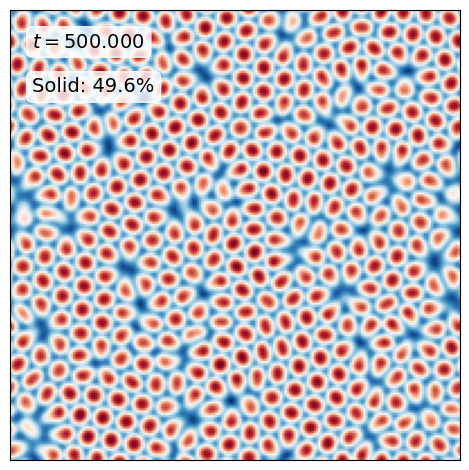

In [11]:
ph.solve(compute_hyperuniformity=False, # turning this off to avoid computation of hyperuniformity 
         kx = cp.asarray(kx),ky=cp.asarray(ky), 
         nu =1, kappa=1, lam =2, alpha= 0.225)

(200, 200) (200, 200)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$q_{y}$ ($\\mathrm{\\mu}$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mathrm{\\mu}$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

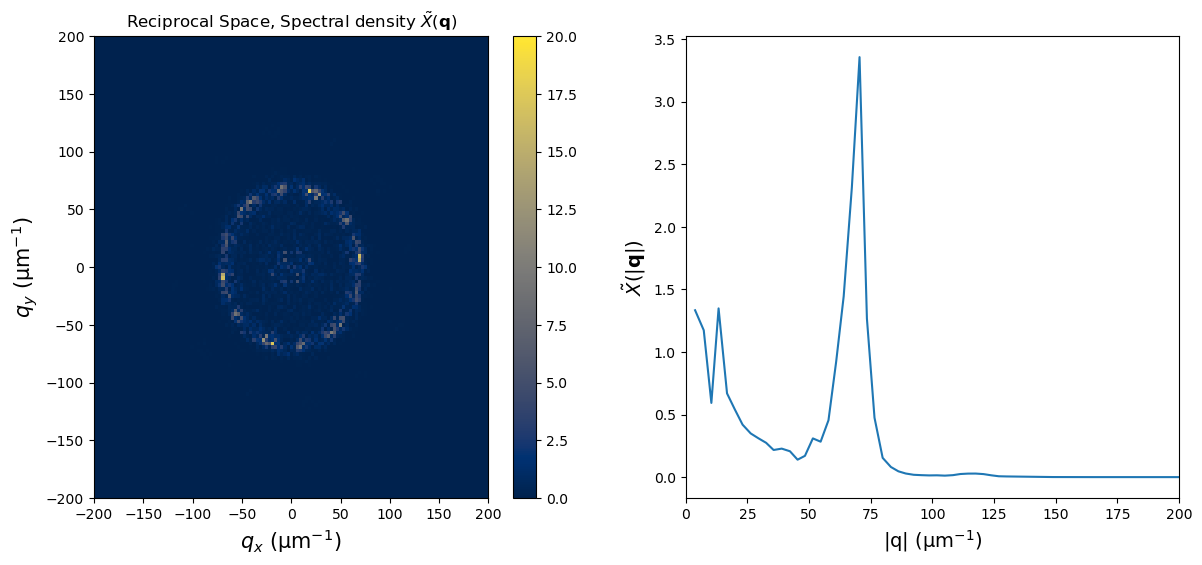

In [12]:
phase_final = ph.final_state

fig = tost.Visualize(phase_final)
fig.plot_reciprocal_space(kmax=200)